In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
#  add light grid to adll figs
plt.rcParams.update({
        "text.usetex": False,          # disable system LaTeX
        "mathtext.fontset": "stix",    # nicer math font
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "grid.color": "lightgray",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
    })

In [4]:
def concat_results(base_dir, mode):
    df_list = []
    # 20, 30, 40, 50, 60, 70, 80, 90,
    for t in [0, 100]:
        df = pd.read_csv(f"{base_dir}/full_results_{mode}_t{t}.csv")
        df["t"] = t
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

In [5]:
# theoretical recall @ 10 vs step
# on SIFT/MSTuring Static sets
# surge & gp-ann
# TODO: compute real imbalance information for all

In [6]:
# gp-ann to generate: (also computes real recall, runs in distributed setting)
# 1. python extract_first_batch.py
# 2. ./Partition - partitions on first batch
# 2. ./DistributedInsertBenchSweep

# surge - to generate:
# 1. ./bin/msturing-cluster-analysis
# 2. ./bin/runbook_partitions_parallel
# 3. python compute_theoretical_recall_updated.py


# /dataset/surge/results/runbook_theoretical_runs/bigann-clustered/full_results_sweep_t0.csv
# /dataset/gp-ann-inserts/results/msturing100Mclustered_runbook_results_nprobe5.csv

In [7]:
# runbook phases for plotting
# step 0-128: insert
# step 128-256: delete
# step 256-384: insert
# step 384-512: delete
# step 512-640: insert
# step 640-768: delete
# step 768-896: insert
# step 896-1024: delete
# step 1024-1152: insert
# step 1152-1280: delete

# shift runbook phases:
# step 0-208: insert
# step 208-245: delete
# step 235-338: insert
# step 338-364: delete
# step 365-468: insert
# step 468-494: delete
# step 495-590: insert
# step 591-616: delete

In [8]:
no_rebuilds_color = "firebrick"
no_rebuilds_label = "no maintenance"

rebuilds_color = "forestgreen"
rebuilds_label = "with maintenance"

In [9]:
# bigann_clustered_path = "/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10/full_results_RecallTarget.csv"
# bigann_clustered = pd.read_csv(bigann_clustered_path)
bigann_clustered_path = "/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10"
bigann_clustered_recalltarget = concat_results(bigann_clustered_path, "RecallTargetExtended")
# bigann_clustered_bf = concat_results(bigann_clustered_path, "BranchingFactor")
# bigann_clustered_nprobe = concat_results(bigann_clustered_path, "NProbe")

# concatenate all bigann clustered results into one dataframe
bigann_clustered = pd.concat([bigann_clustered_recalltarget], axis=0)

gpann_bigann_clustered = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-clustered/gpann_partitions/bigann100Mclustered_runbook_results_nprobe_with_theo_sweep.csv")

In [10]:
bigann_random_path = "/dataset/big-ann-benchmarks/data/bigann-random/cluster_history_bigann-100M-random_10000_10"
bigann_random_recalltarget = concat_results(bigann_random_path, "RecallTargetExtended")
# bigann_random_bf = concat_results(bigann_random_path, "BranchingFactor")
# bigann_random_nprobe = concat_results(bigann_random_path, "NProbe")

bigann_random = pd.concat([bigann_random_recalltarget], axis=0)

gpann_bigann_random = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-random/gpann_partitions/bigann100Mrandom_runbook_results_nprobe_with_theo_sweep.csv")

In [11]:
msturing_random_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-random/cluster_history_msturing-100M-random_10000_10"
msturing_random_recalltarget = concat_results(msturing_random_path, "RecallTargetExtended")
# msturing_random_bf = concat_results(msturing_random_path, "BranchingFactor")
# msturing_random_nprobe = concat_results(msturing_random_path, "NProbe")

msturing_random = pd.concat([msturing_random_recalltarget], axis=0)

# but gpann reports real recall
gpann_msturing_random = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-random/gpann_partitions/msturing100Mrandom_runbook_results_nprobe_with_theo_sweep.csv")

In [12]:
msturing_clustered_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/cluster_history_msturing-100M-clustered_10000_10"
msturing_clustered_recalltarget = concat_results(msturing_clustered_path, "RecallTargetExtended")
# msturing_clustered_bf = concat_results(msturing_clustered_path, "BranchingFactor")
# msturing_clustered_nprobe = concat_results(msturing_clustered_path, "NProbe")

msturing_clustered = pd.concat([msturing_clustered_recalltarget], axis=0)

gpann_msturing_clustered = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/gpann_partitions/msturing100Mclustered_runbook_results_nprobe_with_theo_sweep.csv")

In [13]:
msturing_shift_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10"
msturing_shift_recalltarget = concat_results(msturing_shift_path, "RecallTargetExtended")
# msturing_shift_bf = concat_results(msturing_shift_path, "BranchingFactor")
# msturing_shift_nprobe = concat_results(msturing_shift_path, "NProbe")

msturing_shift = pd.concat([msturing_shift_recalltarget], axis=0)

gpann_msturing_shift = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/gpann_partitions/msturing100Mshift_runbook_results_nprobe_with_theo_sweep.csv")

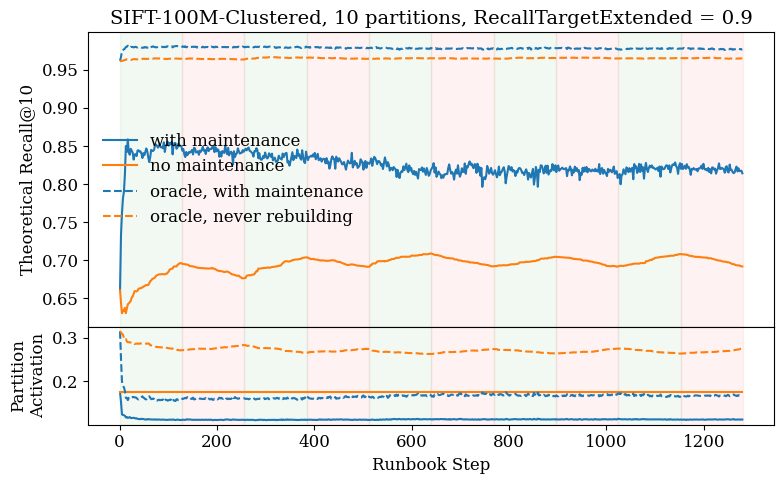

In [15]:
mode = "RecallTargetExtended"
param = .9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
# set size
fig.set_size_inches(8, 5)

ax1.set_title(f"SIFT-100M-Clustered, 10 partitions, {mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=rebuilds_label,
)

ax1.plot(
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=no_rebuilds_label,
)


ax1.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label=f"oracle, {rebuilds_label}", color="C0", ls="--")

ax1.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["recall"],
    label="oracle, never rebuilding", color="C1", ls="--")

ax1.legend(frameon=False)

ax2.plot(
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["activation"],
    label="always rebuilding"
)

ax2.plot(
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == mode) &
                  (bigann_clustered["param"] == param)
                 ]["activation"],
    label="never rebuilding"
)

ax2.plot(bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 0) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["activation"],
    label="oracle, always rebuilding", color="C0", ls="--")

ax2.plot(bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["step"],
    bigann_clustered[(bigann_clustered["t"] == 100) &
                  (bigann_clustered["mode"] == "Oracle") &
                  (bigann_clustered["param"] == param)
                 ]["activation"],
    label="oracle, never rebuilding", color="C1", ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)


fig.tight_layout()

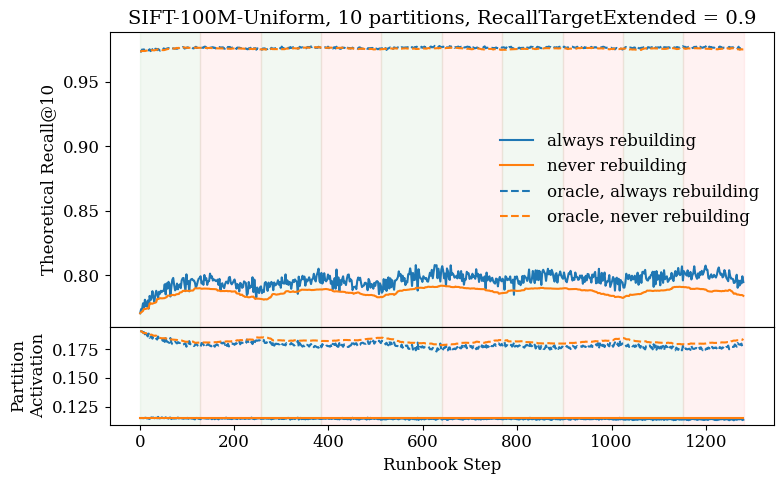

In [16]:
mode = "RecallTargetExtended"
param = .9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
# set size
fig.set_size_inches(8, 5)

ax1.set_title(f"SIFT-100M-Uniform, 10 partitions, {mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label="always rebuilding"
)

ax1.plot(
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label="never rebuilding"
)

# ax1.plot(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="sometimes rebuilding (t=70%)"
# )

# ax1.scatter(
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == mode) &
#                   (bigann_clustered_recalltarget["param"] == param) &
#                   (bigann_clustered_recalltarget["did_rebuild"] == True)
#                  ]["recall"],
#     color="red", marker="x"
# )

ax1.plot(bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label="oracle, always rebuilding", color="C0", ls="--")

ax1.plot(bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["recall"],
    label="oracle, never rebuilding", color="C1", ls="--")

# ax1.plot(bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["step"],
#     bigann_clustered_recalltarget[(bigann_clustered_recalltarget["t"] == 70) &
#                   (bigann_clustered_recalltarget["mode"] == "Oracle") &
#                   (bigann_clustered_recalltarget["param"] == param)
#                  ]["recall"],
#     label="oracle, t=70%", color="C2", ls="--")

ax1.legend(frameon=False)

ax2.plot(
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["activation"],
    label="always rebuilding"
)

ax2.plot(
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == mode) &
                  (bigann_random["param"] == param)
                 ]["activation"],
    label="never rebuilding"
)

ax2.plot(bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 0) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["activation"],
    label="oracle, always rebuilding", color="C0", ls="--")

ax2.plot(bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["step"],
    bigann_random[(bigann_random["t"] == 100) &
                  (bigann_random["mode"] == "Oracle") &
                  (bigann_random["param"] == param)
                 ]["activation"],
    label="oracle, never rebuilding", color="C1", ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)

fig.tight_layout()

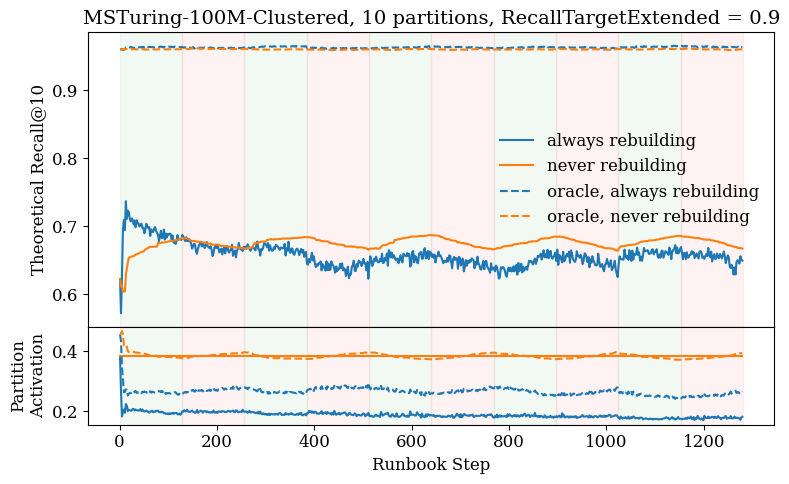

In [17]:
mode = "RecallTargetExtended"
param = .9
gpann_param = 5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
# set size
fig.set_size_inches(8, 5)

ax1.set_title(f"MSTuring-100M-Clustered, 10 partitions, {mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label="always rebuilding"
)

ax1.plot(
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label="never rebuilding"
)

ax1.plot(msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label="oracle, always rebuilding", color="C0", ls="--")

ax1.plot(msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["recall"],
    label="oracle, never rebuilding", color="C1", ls="--")

ax1.legend(frameon=False)

ax2.plot(
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["activation"],
    label="always rebuilding"
)

ax2.plot(
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == mode) &
                  (msturing_clustered["param"] == param)
                 ]["activation"],
    label="never rebuilding"
)

ax2.plot(msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 0) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["activation"],
    label="oracle, always rebuilding", color="C0", ls="--")

ax2.plot(msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["step"],
    msturing_clustered[(msturing_clustered["t"] == 100) &
                  (msturing_clustered["mode"] == "Oracle") &
                  (msturing_clustered["param"] == param)
                 ]["activation"],
    label="oracle, never rebuilding", color="C1", ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)


fig.tight_layout()

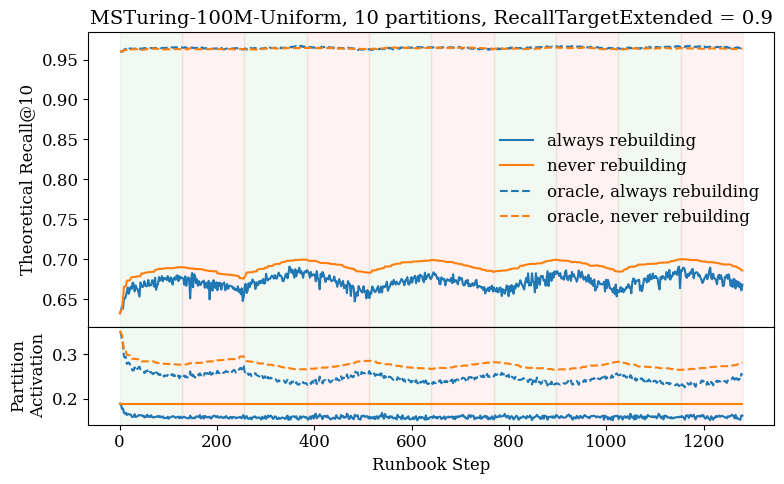

In [18]:
mode = "RecallTargetExtended"
param = .9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
# set size
fig.set_size_inches(8, 5)

ax1.set_title(f"MSTuring-100M-Uniform, 10 partitions, {mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label="always rebuilding"
)

ax1.plot(
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label="never rebuilding"
)

ax1.plot(msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label="oracle, always rebuilding", color="C0", ls="--")

ax1.plot(msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["recall"],
    label="oracle, never rebuilding", color="C1", ls="--")

ax1.legend(frameon=False)

ax2.plot(
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["activation"],
    label="always rebuilding"
)

ax2.plot(
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == mode) &
                  (msturing_random["param"] == param)
                 ]["activation"],
    label="never rebuilding"
)

ax2.plot(msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 0) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["activation"],
    label="oracle, always rebuilding", color="C0", ls="--")

ax2.plot(msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["step"],
    msturing_random[(msturing_random["t"] == 100) &
                  (msturing_random["mode"] == "Oracle") &
                  (msturing_random["param"] == param)
                 ]["activation"],
    label="oracle, never rebuilding", color="C1", ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)

fig.tight_layout()

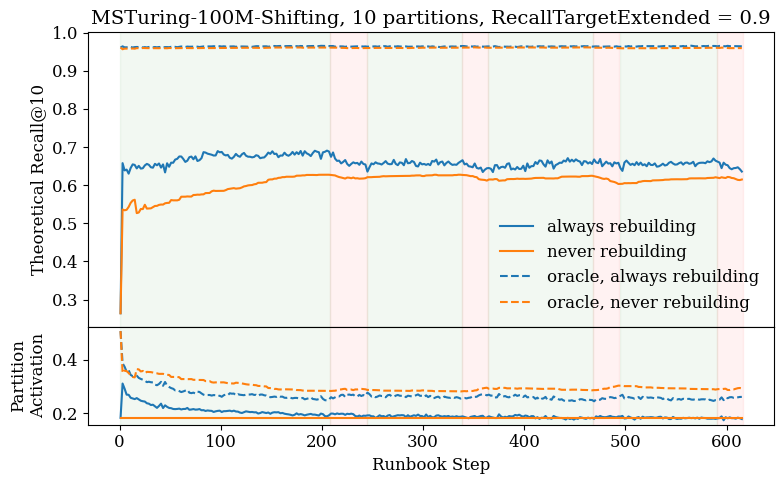

In [19]:
mode = "RecallTargetExtended"
param = .9
gpann_param = 5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})
# set size
fig.set_size_inches(8, 5)

ax1.set_title(f"MSTuring-100M-Shifting, 10 partitions, {mode} = {param}")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label="always rebuilding"
)

ax1.plot(
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label="never rebuilding"
)

ax1.plot(msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label="oracle, always rebuilding", color="C0", ls="--")

ax1.plot(msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["recall"],
    label="oracle, never rebuilding", color="C1", ls="--")

ax1.legend(frameon=False)

ax2.plot(
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["activation"],
    label="always rebuilding"
)

ax2.plot(
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == mode) &
                  (msturing_shift["param"] == param)
                 ]["activation"],
    label="never rebuilding"
)

ax2.plot(msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 0) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["activation"],
    label="oracle, always rebuilding", color="C0", ls="--")

ax2.plot(msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["step"],
    msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "Oracle") &
                  (msturing_shift["param"] == param)
                 ]["activation"],
    label="oracle, never rebuilding", color="C1", ls="--")

ax2.set_xlabel("Runbook Step")
ax2.set_ylabel("Partition\nActivation")

# color in insert/delete phases for shifting dataset
# shift runbook phases:
# step 0-208: insert
# step 208-245: delete
# step 235-338: insert
# step 338-364: delete
# step 365-468: insert
# step 468-494: delete
# step 495-590: insert
# step 591-616: delete

ax1.axvspan(0, 208, color="green", alpha=0.05)
ax1.axvspan(208, 245, color="red", alpha=0.05)
ax1.axvspan(245, 338, color="green", alpha=0.05)
ax1.axvspan(338, 364, color="red", alpha=0.05)
ax1.axvspan(364, 468, color="green", alpha=0.05)
ax1.axvspan(468, 494, color="red", alpha=0.05)
ax1.axvspan(495, 590, color="green", alpha=0.05)
ax1.axvspan(590, 616, color="red", alpha=0.05)

ax2.axvspan(0, 208, color="green", alpha=0.05)
ax2.axvspan(208, 245, color="red", alpha=0.05)
ax2.axvspan(245, 338, color="green", alpha=0.05)
ax2.axvspan(338, 364, color="red", alpha=0.05)
ax2.axvspan(364, 468, color="green", alpha=0.05)
ax2.axvspan(468, 494, color="red", alpha=0.05)
ax2.axvspan(495, 590, color="green", alpha=0.05)
ax2.axvspan(590, 616, color="red", alpha=0.05)


fig.tight_layout()

In [1]:
import pandas as pd, numpy as np, ast

In [2]:
rebuild_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/cluster_history_msturing-100M-clustered_10000_10/per_query_rankings_RecallTargetExtended_t0.csv"
no_rebuild_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/cluster_history_msturing-100M-clustered_10000_10/per_query_rankings_RecallTargetExtended_t100.csv"

In [3]:
df = pd.read_csv(rebuild_path)
for col in ["rt_ranking", "rt_scores", "oracle_ranking", "oracle_scores"]:
    df[col] = df[col].map(ast.literal_eval)
P = len(df["rt_ranking"].iloc[0])

In [5]:
def overlap_at_k(rt, oc, k):
    return len(set(rt[:k]) & set(oc[:k])) / k

for k in range(1, P+1):
    df[f"extended overlap@{k}"] = df.apply(
        lambda r: overlap_at_k(r.rt_ranking, r.oracle_ranking, k), axis=1)

print(df.groupby("step")[[f"extended overlap@{k}" for k in (1,2,3,5,P)]].mean())

      extended overlap@1  extended overlap@2  extended overlap@3  \
step                                                               
1                 0.4142             0.46940            0.513300   
201               0.5746             0.61760            0.648500   
401               0.5416             0.58255            0.597033   
601               0.5835             0.59425            0.599867   
801               0.5472             0.58665            0.614667   
1001              0.5781             0.59870            0.599067   
1201              0.5637             0.58745            0.595533   

      extended overlap@5  extended overlap@10  
step                                           
1                0.61256                  1.0  
201              0.69354                  1.0  
401              0.64078                  1.0  
601              0.64422                  1.0  
801              0.64678                  1.0  
1001             0.66060                  1.0  
120

In [ ]:
#       overlap@1  overlap@2  overlap@3  overlap@5  overlap@10
# step                                                        
# 1        0.3670    0.44710   0.507633    0.62490         1.0
# 201      0.5602    0.62755   0.667833    0.70652         1.0
# 401      0.5007    0.57815   0.599800    0.64630         1.0
# 601      0.5584    0.60675   0.609100    0.64900         1.0
# 801      0.4986    0.57090   0.621600    0.64992         1.0
# 1001     0.5441    0.59820   0.612633    0.66648         1.0
# 1201     0.5249    0.57750   0.601033    0.68808         1.0

#       extended overlap@1  extended overlap@2  extended overlap@3  \
# step                                                               
# 1                 0.4142             0.46940            0.513300   
# 201               0.5746             0.61760            0.648500   
# 401               0.5416             0.58255            0.597033   
# 601               0.5835             0.59425            0.599867   
# 801               0.5472             0.58665            0.614667   
# 1001              0.5781             0.59870            0.599067   
# 1201              0.5637             0.58745            0.595533   

#       extended overlap@5  extended overlap@10  
# step                                           
# 1                0.61256                  1.0  
# 201              0.69354                  1.0  
# 401              0.64078                  1.0  
# 601              0.64422                  1.0  
# 801              0.64678                  1.0  
# 1001             0.66060                  1.0  
# 1201             0.67664                  1.0

In [35]:
def true_recall_at_k(rt_ranking, oracle_ranking, oracle_scores, k):
    density = dict(zip(oracle_ranking, oracle_scores))
    return sum(density[p] for p in rt_ranking[:k])

for k in range(1, P+1):
    df[f"rtextended_true_recall@{k}"] = df.apply(
        lambda r: true_recall_at_k(r.rt_ranking, r.oracle_ranking, r.oracle_scores, k),
        axis=1)
    df[f"oracle_recall@{k}"] = df["oracle_scores"].map(lambda s: sum(s[:k]))

summary = pd.DataFrame({
    "rtextended_recall":    [df[f"rtextended_true_recall@{k}"].mean() for k in range(1, P+1)],
    "oracle_recall":[df[f"oracle_recall@{k}"].mean()  for k in range(1, P+1)],
})
summary["gap"] = summary["oracle_recall"] - summary["rtextended_recall"]
print(summary)

   rtextended_recall  oracle_recall       gap
0           0.443659       0.630267  0.186609
1           0.636643       0.825449  0.188806
2           0.749460       0.917910  0.168450
3           0.826987       0.964877  0.137890
4           0.882316       0.988239  0.105923
5           0.922061       0.997300  0.075239
6           0.950483       0.999656  0.049173
7           0.970956       0.999987  0.029031
8           0.985563       1.000000  0.014437
9           1.000000       1.000000  0.000000


In [ ]:
#    rt_recall  oracle_recall       gap
# 0   0.418520       0.630267  0.211747
# 1   0.627013       0.825449  0.198436
# 2   0.754574       0.917910  0.163336
# 3   0.836407       0.964877  0.128470
# 4   0.890584       0.988239  0.097654
# 5   0.926994       0.997300  0.070306
# 6   0.952804       0.999656  0.046851
# 7   0.971559       0.999987  0.028429
# 8   0.985606       1.000000  0.014394
# 9   1.000000       1.000000  0.000000


#    rtextended_recall  oracle_recall       gap
# 0           0.443659       0.630267  0.186609
# 1           0.636643       0.825449  0.188806
# 2           0.749460       0.917910  0.168450
# 3           0.826987       0.964877  0.137890
# 4           0.882316       0.988239  0.105923
# 5           0.922061       0.997300  0.075239
# 6           0.950483       0.999656  0.049173
# 7           0.970956       0.999987  0.029031
# 8           0.985563       1.000000  0.014437
# 9           1.000000       1.000000  0.000000